# Tabular Pipeline — Aeolus Flight Delay Project

This notebook builds and validates the full tabular pipeline for flight delay prediction on a **synthetic dataset that replicates the exact schema of Aeolus** (Xu et al., 2025). It exists so that data preprocessing, feature engineering, model training, and evaluation can all be developed and tested *before* the real cleaned dataset is available from the teammate handling data preparation.

**How to use this now:** run every cell in order — it works immediately on the synthetic data, and every intermediate result (splits, features, metrics) is fully inspectable.

**How to switch to real data later:** modify **only** the `get_data()` function in Section 2. Nothing else in this notebook needs to change, as long as the real dataset's columns match the schema defined in Section 1.

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, classification_report
import torch
import torch.nn as nn
import optuna
import shap


/home/sara/NeuralNetwork&DeepLearning/Flight-Delay-Forecasting/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Reference schema (Aeolus, Table 9 of the paper)

This defines the exact set of columns the real dataset must provide: 8 categorical fields (carrier, flight number, date components, origin/destination airport codes), 14 continuous fields (scheduled times, weather at origin/destination, geographic coordinates), and 2 target columns (departure and arrival delay in minutes).

**This is the single most important thing to align on with the teammate cleaning the data.** If the real dataset uses these exact column names (case-sensitive), plugging it in later takes one line of code. If the names differ, either ask them to match this schema, or rename the columns yourself with `df.rename(columns=...)` once the data arrives — don't rewrite the pipeline.

In [2]:
CATEGORICAL_COLS = [
    "OP_CARRIER", "OP_CARRIER_FL_NUM", "FL_YEAR", "FL_MONTH",
    "FL_DAY", "FL_WEEK", "ORIGIN_INDEX", "DEST_INDEX",
]
CONTINUOUS_COLS = [
    "CRS_DEP_TIME_MIN", "CRS_ARR_TIME_MIN", "CRS_ELAPSED_TIME", "FLIGHTS",
    "O_TEMP", "O_PRCP", "O_WSPD", "D_TEMP", "D_PRCP", "D_WSPD",
    "O_LATITUDE", "O_LONGITUDE", "D_LATITUDE", "D_LONGITUDE",
]
TARGET_COLS = ["DEP_DELAY", "ARR_DELAY"]


## 2. Data loading

### Using it now (synthetic data)
The function below generates **fake but internally consistent** data: valid calendar dates, airports with fixed and consistent coordinates, and delays that are correlated with weather, rush hours, and season, following a right-skewed distribution similar to real flight delay data (see Figure 4 of the Aeolus paper). This exists purely to build and stress-test the pipeline before real data is ready — the numbers themselves have no real-world meaning.

### Switching to real data (when ready)
Replace the body of `get_data()` with:
```python
def get_data():
    return pd.read_parquet("path/to/real_dataset.parquet")
```
Nothing else needs to change, provided the columns match the schema from Section 1.

In [ ]:
def generate_mock_data(n_rows: int = 200_000, seed: int = 42) -> pd.DataFrame:
    """Generated n_rows of fake data with same schema as Aeolus."""
    rng = np.random.default_rng(seed)

    # 40 fake aeroports with plausible coordinates
    n_airports = 40
    airport_codes = [f"A{str(i).zfill(3)}" for i in range(n_airports)]
    airport_lat = rng.uniform(25, 48, n_airports)
    airport_lon = rng.uniform(-122, -71, n_airports)
    airport_coord = {c: (la, lo) for c, la, lo in zip(airport_codes, airport_lat, airport_lon)}

    # 15 fake companies
    carriers = [f"C{str(i).zfill(2)}" for i in range(15)]

    # random dates between 2022-01-01 and 2024-12-31   
    date_range = pd.date_range("2022-01-01", "2024-12-31", freq="D")
    dates = pd.to_datetime(rng.choice(date_range, size=n_rows))

    #  origin/destination (different between them) 
    origin = rng.choice(airport_codes, size=n_rows)
    dest = np.array([rng.choice([c for c in airport_codes if c != o]) for o in origin])

    o_lat = np.array([airport_coord[c][0] for c in origin])
    o_lon = np.array([airport_coord[c][1] for c in origin])
    d_lat = np.array([airport_coord[c][0] for c in dest])
    d_lon = np.array([airport_coord[c][1] for c in dest])

    # scheduled times
    crs_dep_time_min = rng.integers(0, 1440, n_rows)
    crs_elapsed_time = rng.integers(40, 360, n_rows)
    crs_arr_time_min = (crs_dep_time_min + crs_elapsed_time) % 1440

    # synthetic weather data with month-based seasonality   
    month = dates.month.values
    seasonal_temp = 15 + 15 * np.sin((month - 3) / 12 * 2 * np.pi)
    o_temp = seasonal_temp + rng.normal(0, 8, n_rows)
    d_temp = seasonal_temp + rng.normal(0, 8, n_rows)
    o_prcp = rng.exponential(0.05, n_rows)
    d_prcp = rng.exponential(0.05, n_rows)
    o_wspd = rng.gamma(2, 4, n_rows)
    d_wspd = rng.gamma(2, 4, n_rows)

    flights = np.ones(n_rows, dtype=int)
    fl_num = rng.integers(100, 9999, n_rows)
    carrier = rng.choice(carriers, size=n_rows)

    # delay generation: base + weather + peak hour
    peak_hour_effect = np.where(
        (crs_dep_time_min % 1440 > 6 * 60) & (crs_dep_time_min % 1440 < 9 * 60), 6, 0
    ) + np.where(
        (crs_dep_time_min % 1440 > 16 * 60) & (crs_dep_time_min % 1440 < 20 * 60), 8, 0
    )
    weather_effect = 0.8 * o_prcp * 60 + 0.3 * o_wspd
    base_noise = rng.gumbel(loc=-3, scale=9, size=n_rows)  # right-skewed as in real data

    dep_delay = base_noise + peak_hour_effect + weather_effect
    arr_delay = dep_delay + rng.normal(0, 6, n_rows) - 0.05 * crs_elapsed_time

    df = pd.DataFrame({
        "OP_CARRIER": carrier,
        "OP_CARRIER_FL_NUM": fl_num,
        "FL_YEAR": dates.year.values,
        "FL_MONTH": dates.month.values,
        "FL_DAY": dates.day.values,
        "FL_WEEK": dates.isocalendar().week.values,
        "ORIGIN_INDEX": origin,
        "DEST_INDEX": dest,
        "CRS_DEP_TIME_MIN": crs_dep_time_min,
        "CRS_ARR_TIME_MIN": crs_arr_time_min,
        "CRS_ELAPSED_TIME": crs_elapsed_time,
        "FLIGHTS": flights,
        "O_TEMP": o_temp, "O_PRCP": o_prcp, "O_WSPD": o_wspd,
        "D_TEMP": d_temp, "D_PRCP": d_prcp, "D_WSPD": d_wspd,
        "O_LATITUDE": o_lat, "O_LONGITUDE": o_lon,
        "D_LATITUDE": d_lat, "D_LONGITUDE": d_lon,
        "DEP_DELAY": dep_delay,
        "ARR_DELAY": arr_delay,
        "_FLIGHT_DATE": dates,
    })
    return df.sort_values("_FLIGHT_DATE").reset_index(drop=True)


def get_data(n_rows: int = 1_000_000) -> pd.DataFrame:
    """<<< SUBSTITUTE THIS FUNCTION WITH THE LOADING OF REAL DATA >>>"""
    return generate_mock_data(n_rows=n_rows)


df = get_data()
print(df.shape)
df.head()


(1000000, 25)


,OP_CARRIER,OP_CARRIER_FL_NUM,FL_YEAR,FL_MONTH,FL_DAY,FL_WEEK,ORIGIN_INDEX,DEST_INDEX,CRS_DEP_TIME_MIN,CRS_ARR_TIME_MIN,...,D_TEMP,D_PRCP,D_WSPD,O_LATITUDE,O_LONGITUDE,D_LATITUDE,D_LONGITUDE,DEP_DELAY,ARR_DELAY,_FLIGHT_DATE
0,C01,2297,2022,1,1,52,A000,A013,965,1261,...,-1.829533,0.025324,15.014967,42.800989,-99.705252,43.923517,-88.092606,16.025429,11.359255,2022-01-01
1,C07,3749,2022,1,1,52,A000,A030,372,523,...,7.689900,0.131837,3.112636,42.800989,-99.705252,42.129530,-111.056182,0.458096,-4.702213,2022-01-01
2,C05,2806,2022,1,1,52,A004,A019,241,567,...,11.638743,0.058083,4.074531,27.166079,-79.554750,39.528281,-116.158966,11.329019,-2.031605,2022-01-01
3,C01,2298,2022,1,1,52,A008,A022,486,587,...,8.920823,0.130000,18.000911,27.946614,-87.192729,47.326055,-93.172959,41.425033,29.125886,2022-01-01
4,C08,4868,2022,1,1,52,A002,A031,486,770,...,2.439463,0.179118,3.163098,44.747752,-86.286480,47.252724,-101.165039,4.818230,4.061259,2022-01-01


### 2b. Dataset validation

Before running the real dataset through this pipeline, it's worth checking it actually matches what the pipeline expects — wrong column names, unexpected missing values, or out-of-range coordinates are much easier to catch here than three cells later inside a cryptic LightGBM error. This function is tested below on both a clean and a deliberately broken version of the mock data, to confirm it catches real issues.


In [4]:
def validate_dataset(df: pd.DataFrame, verbose: bool = True) -> dict:
    """Checks the dataset against the expected Aeolus schema before running
    the rest of the pipeline on it. Returns a report dict; does not modify df."""
    report = {"errors": [], "warnings": [], "info": []}

    expected_cols = CATEGORICAL_COLS + CONTINUOUS_COLS + TARGET_COLS
    missing_cols = [c for c in expected_cols if c not in df.columns]
    extra_cols = [c for c in df.columns if c not in expected_cols and c != "_FLIGHT_DATE"]
    if missing_cols:
        report["errors"].append(f"Missing expected columns: {missing_cols}")
    if extra_cols:
        report["warnings"].append(f"Extra columns not in schema (fine if intentional): {extra_cols}")

    present_cols = [c for c in expected_cols if c in df.columns]

    na_counts = df[present_cols].isna().sum()
    na_cols = na_counts[na_counts > 0]
    if len(na_cols) > 0:
        pct = (na_cols / len(df) * 100).round(2)
        report["warnings"].append(
            "Missing values found:\n" + pd.concat([na_cols, pct], axis=1, keys=["n_missing", "pct"]).to_string()
        )

    n_dup = df.duplicated().sum()
    if n_dup > 0:
        report["warnings"].append(f"{n_dup} duplicate rows found ({n_dup/len(df)*100:.2f}%)")

    range_checks = {
        "O_LATITUDE": (-90, 90), "D_LATITUDE": (-90, 90),
        "O_LONGITUDE": (-180, 180), "D_LONGITUDE": (-180, 180),
        "CRS_DEP_TIME_MIN": (0, 1439), "CRS_ARR_TIME_MIN": (0, 1439),
        "CRS_ELAPSED_TIME": (0, 24 * 60),
        "O_PRCP": (0, None), "D_PRCP": (0, None),
        "O_WSPD": (0, None), "D_WSPD": (0, None),
    }
    for col, (lo, hi) in range_checks.items():
        if col not in df.columns:
            continue
        n_bad = len(df[df[col] < lo]) + (len(df[df[col] > hi]) if hi is not None else 0)
        if n_bad > 0:
            report["warnings"].append(f"{col}: {n_bad} rows outside plausible range [{lo}, {hi}]")

    for col in TARGET_COLS:
        if col not in df.columns:
            continue
        extreme = df[(df[col] < -60) | (df[col] > 1440)]
        if len(extreme) > 0:
            report["warnings"].append(f"{col}: {len(extreme)} extreme values (< -60 min or > 1440 min) — worth checking, not necessarily errors")

    for col in CATEGORICAL_COLS:
        if col in df.columns:
            report["info"].append(f"{col}: {df[col].nunique()} unique values")

    report["info"].append(f"Dataset shape: {df.shape}")

    if verbose:
        print("=== VALIDATION REPORT ===")
        print("\n❌ ERRORS (blocking):" if report["errors"] else "\n✅ No blocking errors")
        for e in report["errors"]:
            print(" -", e)
        if report["warnings"]:
            print("\n⚠️  WARNINGS (worth checking):")
            for w in report["warnings"]:
                print(" -", w)
        print("\nℹ️  INFO:")
        for i in report["info"]:
            print(" -", i)

    return report


# Run it on the currently loaded dataset (mock now, real data later — nothing else to change)
validation_report = validate_dataset(df)

=== VALIDATION REPORT ===

✅ No blocking errors

ℹ️  INFO:
 - OP_CARRIER: 15 unique values
 - OP_CARRIER_FL_NUM: 9899 unique values
 - FL_YEAR: 3 unique values
 - FL_MONTH: 12 unique values
 - FL_DAY: 31 unique values
 - FL_WEEK: 52 unique values
 - ORIGIN_INDEX: 40 unique values
 - DEST_INDEX: 40 unique values
 - Dataset shape: (1000000, 25)


## 3. Feature engineering

Adds derived features on top of the 22 native Aeolus columns, inspired by the literature review for this project:

- **Cyclical time features** (sine/cosine of hour-of-day, day-of-week, month): preserves continuity around midnight/year-end, which raw integers or one-hot encoding would break.
- **Great-circle distance**: computed from the origin/destination lat/lon coordinates already present in Aeolus.
- **Airport congestion proxy**: number of flights scheduled from the same origin airport, on the same day, within the same 2-hour window. This is based only on *scheduled* times, so it introduces no leakage and is safe to compute before the temporal split.
- **Binary delay target**: flags a flight as delayed if it exceeds the 15-minute threshold, matching Aeolus's own official benchmark for direct comparability.

In [25]:
def add_cyclic_time_features(df: pd.DataFrame) -> pd.DataFrame:
    """Hour of day and day of week as sine/cosine instead of raw integers:
    preserves continuity (23:59 close to 00:00)."""
    df = df.copy()
    minutes_in_day = 24 * 60

    df["dep_hour_sin"] = np.sin(2 * np.pi * df["CRS_DEP_TIME_MIN"] / minutes_in_day)
    df["dep_hour_cos"] = np.cos(2 * np.pi * df["CRS_DEP_TIME_MIN"] / minutes_in_day)
    df["arr_hour_sin"] = np.sin(2 * np.pi * df["CRS_ARR_TIME_MIN"] / minutes_in_day)
    df["arr_hour_cos"] = np.cos(2 * np.pi * df["CRS_ARR_TIME_MIN"] / minutes_in_day)

    date = pd.to_datetime(dict(year=df["FL_YEAR"], month=df["FL_MONTH"], day=df["FL_DAY"]))
    dow = date.dt.dayofweek
    df["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    df["dow_cos"] = np.cos(2 * np.pi * dow / 7)
    df["month_sin"] = np.sin(2 * np.pi * df["FL_MONTH"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["FL_MONTH"] / 12)
    return df


def add_great_circle_distance(df: pd.DataFrame) -> pd.DataFrame:
    """Great-circle distance (Haversine, km) between origin and destination."""
    df = df.copy()
    R = 6371.0
    lat1, lon1 = np.radians(df["O_LATITUDE"]), np.radians(df["O_LONGITUDE"])
    lat2, lon2 = np.radians(df["D_LATITUDE"]), np.radians(df["D_LONGITUDE"])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    df["great_circle_km"] = R * 2 * np.arcsin(np.sqrt(a))
    return df


def add_airport_congestion(df: pd.DataFrame) -> pd.DataFrame:
    """Congestion proxy: number of flights scheduled from the same origin
    airport, on the same day, within the same 2-hour window. Based only on
    SCHEDULED times -> no leakage, safe to compute even before the temporal
    split."""   
    df = df.copy()
    df["dep_hour_bucket"] = (df["CRS_DEP_TIME_MIN"] // 120).astype(int)
    congestion = (
        df.groupby(["ORIGIN_INDEX", "FL_YEAR", "FL_MONTH", "FL_DAY", "dep_hour_bucket"])
        .size().rename("origin_congestion_2h").reset_index()
    )
    df = df.merge(congestion, on=["ORIGIN_INDEX", "FL_YEAR", "FL_MONTH", "FL_DAY", "dep_hour_bucket"], how="left")
    return df


def add_binary_target(df: pd.DataFrame, threshold: int = 15) -> pd.DataFrame:
    """Binary target aligned with the official Aeolus benchmark (15-min threshold)."""
    df = df.copy()
    df["ARR_DELAY_BIN"] = (df["ARR_DELAY"] > threshold).astype(int)
    df["DEP_DELAY_BIN"] = (df["DEP_DELAY"] > threshold).astype(int)
    return df
# Here only delays are treated as anomalies. If early arrivals/departures
# should also be treated as anomalies, a negative threshold could be used
# (e.g. -15 min). In that case, the function would become:
#
#def add_binary_target(df: pd.DataFrame, threshold: int = 15, include_early: bool = False) -> pd.DataFrame:
 #   df = df.copy()
  #  if include_early:
   #     # come nella repo ufficiale Aeolus: conta come "delay" sia ritardi che anticipi
    #    df["ARR_DELAY_BIN"] = (df["ARR_DELAY"].abs() > threshold).astype(int)
     #   df["DEP_DELAY_BIN"] = (df["DEP_DELAY"].abs() > threshold).astype(int)
 #   else:
  #      df["ARR_DELAY_BIN"] = (df["ARR_DELAY"] > threshold).astype(int)
   #     df["DEP_DELAY_BIN"] = (df["DEP_DELAY"] > threshold).astype(int)
    #return df

def add_all_features(df: pd.DataFrame, delay_threshold: int = 15) -> pd.DataFrame:
    df = add_cyclic_time_features(df)
    df = add_great_circle_distance(df)
    df = add_airport_congestion(df)
    df = add_binary_target(df, threshold=delay_threshold)
    return df


df = add_all_features(df, delay_threshold=15)
print(df.shape)
print("\nClass balance (ARR_DELAY_BIN):")
print(df["ARR_DELAY_BIN"].value_counts(normalize=True))


(1000000, 39)

Class balance (ARR_DELAY_BIN):
ARR_DELAY_BIN
0    0.869414
1    0.130586
Name: proportion, dtype: float64


## 4. Temporal split (60/20/20, never random)

Splits the dataset chronologically by day into train (60%), validation (20%), and test (20%) sets, preserving time order.

**Why this matters:** Xu et al. (2025) show empirically that a random split inflates AUC by +0.057 on average compared to a temporal split, because it leaks future information into training. A random split would make the model look better than it actually is on unseen, future flights — which is exactly the real-world use case we care about.

In [ ]:
def temporal_split(df: pd.DataFrame, date_col: str = "_FLIGHT_DATE"):
    """Split by day: 60% train, 20% val, 20% test, in chronological order.

    If you are working with real data without a ready date column, reconstruct it with:
        pd.to_datetime(dict(year=df.FL_YEAR, month=df.FL_MONTH, day=df.FL_DAY))
    """
    if date_col not in df.columns:
        df = df.copy()
        df[date_col] = pd.to_datetime(dict(year=df["FL_YEAR"], month=df["FL_MONTH"], day=df["FL_DAY"]))

    df = df.sort_values(date_col).reset_index(drop=True)
    n = len(df)
    train_end, val_end = int(n * 0.6), int(n * 0.8)
    train, val, test = df.iloc[:train_end], df.iloc[train_end:val_end], df.iloc[val_end:]

    print(f"Train: {train[date_col].min().date()} -> {train[date_col].max().date()} ({len(train)} righe)")
    print(f"Val:   {val[date_col].min().date()} -> {val[date_col].max().date()} ({len(val)} righe)")
    print(f"Test:  {test[date_col].min().date()} -> {test[date_col].max().date()} ({len(test)} righe)")
    return train, val, test

# save a copy first that the outlier removel sovrascriva train/val/test
train, val, test = temporal_split(df)
train_raw, val_raw, test_raw = train.copy(), val.copy(), test.copy()



Train: 2022-01-01 -> 2023-10-20 (600000 righe)
Val:   2023-10-20 -> 2024-05-26 (200000 righe)
Test:  2024-05-26 -> 2024-12-31 (200000 righe)


### 4b. Outlier removal 

In [26]:
#  Outlier removal (TRAIN ONLY — val/test stay untouched)
# nella repository Flmnny lo facevano in tutto dataset, ma questo introduce leakage. Meglio calcolare i bound solo sul train e poi applicarli a val/test.


def remove_outliers_train_only(train_df, column, lower=0.01, upper=0.99):
    """Remove extreme delays ONLY from the training set, to stabilize
    learning. Val and test remain untouched: they should represent the
    real distribution that the model will encounter in evaluation/production,
    including extreme cases."""
    lower_bound = train_df[column].quantile(lower)
    upper_bound = train_df[column].quantile(upper)
    print(f"{column}: bound = [{lower_bound:.1f}, {upper_bound:.1f}] min (computed on train)")

    train_clean = train_df[(train_df[column] >= lower_bound) & (train_df[column] <= upper_bound)]
    removed = len(train_df) - len(train_clean)
    print(f"train: removed {removed} flights ({removed/len(train_df)*100:.2f}%)")
    print("val/test: not modified")

    return train_clean, lower_bound, upper_bound


train, lo, hi = remove_outliers_train_only(train, "ARR_DELAY")
# val e test restano quelli originali

ARR_DELAY: bound = [-26.9, 33.2] min (computed on train)
train: removed 11760 flights (2.00%)
val/test: not modified


### 4c. Class balance check (before vs after outlier removal)

Removing extreme delays could plausibly shift the class balance of the binary target, since delays follow a right-skewed distribution — there are more extreme outliers on the "delayed" side than on the "on-time" side. This section checks that directly with numbers and plots, rather than assuming it.

In [8]:
def class_balance_report(splits: dict, target_col: str, label: str = ""):
    """Prints a class balance table for each split (train/val/test)."""
    print(f"\n=== Class balance — {target_col} {label} ===")
    rows = []
    for split_name, split_df in splits.items():
        counts = split_df[target_col].value_counts().sort_index()
        pct = split_df[target_col].value_counts(normalize=True).sort_index() * 100
        rows.append({
            "split": split_name, "n_total": len(split_df),
            "n_on_time": counts.get(0, 0), "n_delayed": counts.get(1, 0),
            "%_delayed": round(pct.get(1, 0), 2),
        })
    report = pd.DataFrame(rows)
    print(report.to_string(index=False))
    return report


# Report BEFORE outlier removal — run this on the splits produced by Section 4,
# saved under different names so they survive the outlier removal step below
report_before = class_balance_report(
    {"train": train_raw, "val": val_raw, "test": test_raw}, "ARR_DELAY_BIN", label="(before outlier removal)"
)

# Outlier removal bounds (reuses the same logic as Section 4bis)
lo = train_raw["ARR_DELAY"].quantile(0.01)
hi = train_raw["ARR_DELAY"].quantile(0.99)
print(f"\nBounds computed on train: [{lo:.1f}, {hi:.1f}] minutes")

report_after = class_balance_report(
    {"train": train, "val": val, "test": test}, "ARR_DELAY_BIN", label="(after outlier removal)"
)

# Direct comparison
comparison = report_before[["split", "%_delayed"]].merge(
    report_after[["split", "%_delayed"]], on="split", suffixes=("_before", "_after")
)
comparison["difference"] = (comparison["%_delayed_after"] - comparison["%_delayed_before"]).round(2)
print("\n=== Direct comparison: % delayed flights, before vs after ===")
print(comparison.to_string(index=False))


=== Class balance — ARR_DELAY_BIN (before outlier removal) ===
split  n_total  n_on_time  n_delayed  %_delayed
train   600000     521651      78349      13.06
  val   200000     173909      26091      13.05
 test   200000     173854      26146      13.07

Bounds computed on train: [-29.7, 39.6] minutes

=== Class balance — ARR_DELAY_BIN (after outlier removal) ===
split  n_total  n_on_time  n_delayed  %_delayed
train   588000     515651      72349      12.30
  val   200000     173909      26091      13.05
 test   200000     173854      26146      13.07

=== Direct comparison: % delayed flights, before vs after ===
split  %_delayed_before  %_delayed_after  difference
train             13.06            12.30       -0.76
  val             13.05            13.05        0.00
 test             13.07            13.07        0.00


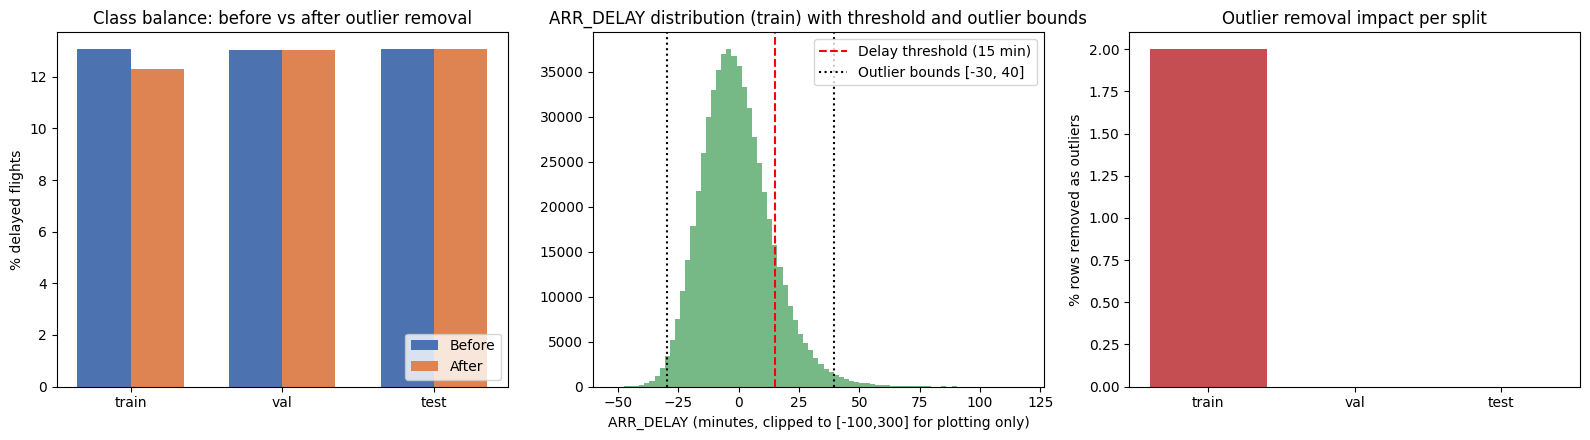

In [9]:
# Visualizations

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

x = np.arange(len(report_before))
width = 0.35
axes[0].bar(x - width/2, report_before["%_delayed"], width, label="Before", color="#4C72B0")
axes[0].bar(x + width/2, report_after["%_delayed"], width, label="After", color="#DD8452")
axes[0].set_xticks(x)
axes[0].set_xticklabels(report_before["split"])
axes[0].set_ylabel("% delayed flights")
axes[0].set_title("Class balance: before vs after outlier removal")
axes[0].legend(loc="lower right")

axes[1].hist(train_raw["ARR_DELAY"].clip(-100, 300), bins=80, color="#55A868", alpha=0.8)
axes[1].axvline(15, color="red", linestyle="--", label="Delay threshold (15 min)")
axes[1].axvline(lo, color="black", linestyle=":", label=f"Outlier bounds [{lo:.0f}, {hi:.0f}]")
axes[1].axvline(hi, color="black", linestyle=":")
axes[1].set_xlabel("ARR_DELAY (minutes, clipped to [-100,300] for plotting only)")
axes[1].set_title("ARR_DELAY distribution (train) with threshold and outlier bounds")
axes[1].legend()

removed_pct = [
    (len(train_raw) - len(train)) / len(train_raw) * 100,
    (len(val_raw) - len(val)) / len(val_raw) * 100,
    (len(test_raw) - len(test)) / len(test_raw) * 100,
]
axes[2].bar(["train", "val", "test"], removed_pct, color="#C44E52")
axes[2].set_ylabel("% rows removed as outliers")
axes[2].set_title("Outlier removal impact per split")

plt.tight_layout()
plt.show()

## 5. Categorical encoding (fit on train only)

Converts categorical columns (carrier, airport codes, etc.) into integer codes using label encoding. The encoder is **fit only on the training set**; any category seen in validation/test but not in training is mapped to a dedicated "unseen" value (-1) rather than crashing the pipeline. Fitting on the full dataset before the split would leak information from validation/test into training — the same leakage principle as the temporal split above, applied to categorical encoding instead of dates.

In [21]:
def encode_categoricals(train, val, test, cat_cols):
    encoders = {}
    train, val, test = train.copy(), val.copy(), test.copy()
    for col in cat_cols:
        le = LabelEncoder()
        le.fit(train[col].astype(str))
        mapping = {cls: i for i, cls in enumerate(le.classes_)}
        for split_df in (train, val, test):
            split_df[col] = split_df[col].astype(str).map(mapping).fillna(-1).astype(int)
        encoders[col] = mapping
    return train, val, test, encoders


cat_cols = CATEGORICAL_COLS
train, val, test, encoders = encode_categoricals(train, val, test, cat_cols)

target_col = "ARR_DELAY_BIN"
exclude_cols = {"ARR_DELAY", "DEP_DELAY", "ARR_DELAY_BIN", "DEP_DELAY_BIN", "_FLIGHT_DATE", "dep_hour_bucket"}
feature_cols = [c for c in train.columns if c not in exclude_cols]
print(f"Feature used ({len(feature_cols)}): {feature_cols}")


Feature used (32): ['OP_CARRIER', 'OP_CARRIER_FL_NUM', 'FL_YEAR', 'FL_MONTH', 'FL_DAY', 'FL_WEEK', 'ORIGIN_INDEX', 'DEST_INDEX', 'CRS_DEP_TIME_MIN', 'CRS_ARR_TIME_MIN', 'CRS_ELAPSED_TIME', 'FLIGHTS', 'O_TEMP', 'O_PRCP', 'O_WSPD', 'D_TEMP', 'D_PRCP', 'D_WSPD', 'O_LATITUDE', 'O_LONGITUDE', 'D_LATITUDE', 'D_LONGITUDE', 'dep_hour_sin', 'dep_hour_cos', 'arr_hour_sin', 'arr_hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'great_circle_km', 'origin_congestion_2h']


## 6. LightGBM baseline training

Trains a gradient-boosted tree classifier on the tabular features, with two choices worth flagging:

- **Class weighting (`scale_pos_weight`)** instead of oversampling techniques like SMOTE, for both speed and scalability — SMOTE becomes prohibitively expensive at the scale of the full Aeolus dataset (54.67M flights).
- **Early stopping** on the validation AUC, so the model doesn't keep training past the point where it starts overfitting.

LightGBM is used as the baseline because it's fast, handles categorical features and large volumes natively, and consistently performs competitively against more complex tabular deep learning models in the literature.

In [27]:
def train_lightgbm(train, val, feature_cols, target_col, cat_cols):
    y_train, y_val = train[target_col], val[target_col]

    # class weighting for the imbalance (no SMOTE on this scale)
    n_pos = y_train.sum()
    n_neg = len(y_train) - n_pos
    scale_pos_weight = n_neg / max(n_pos, 1)
    print(f"scale_pos_weight = {scale_pos_weight:.2f} (positive class: {n_pos}/{len(y_train)})")

    train_set = lgb.Dataset(train[feature_cols], label=y_train, categorical_feature=cat_cols)
    val_set = lgb.Dataset(val[feature_cols], label=y_val, categorical_feature=cat_cols, reference=train_set)

    params = {
        "objective": "binary",
        "metric": ["auc", "binary_logloss"],
        "scale_pos_weight": scale_pos_weight,
        "learning_rate": 0.05,
        "num_leaves": 63,
        "verbose": -1,
    }
    model = lgb.train(
        params, train_set, num_boost_round=500,
        valid_sets=[train_set, val_set], valid_names=["train", "val"],
        callbacks=[lgb.early_stopping(stopping_rounds=20), lgb.log_evaluation(period=50)],
    )
    return model


model = train_lightgbm(train, val, feature_cols, target_col, cat_cols)


scale_pos_weight = 7.67 (positive class: 66469/576240)
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[2]	train's auc: 0.703615	train's binary_logloss: 0.353855	val's auc: 0.683555	val's binary_logloss: 0.37989


## 7. Evaluation

**Why not just use 0.5 as the decision threshold?** With class weighting applied, the model's predicted probabilities are no longer calibrated — using the default 0.5 threshold typically yields an F1 score close to zero, which looks like a bug but isn't. Instead, we search for the threshold that maximizes F1 **on the validation set** (never on the test set, to avoid tuning against the data we're supposed to evaluate on), then apply that fixed threshold to the test set.

**Why report AUC and F1 instead of just Accuracy?** Only ~13% of flights are delayed (matching the real class imbalance in Aeolus). A model that always predicts "on time" would score ~87% accuracy while being completely useless. AUC and F1 account for this imbalance; accuracy on its own is included only as a secondary reference, never as the primary metric.

In [22]:
def find_best_threshold(model, val, feature_cols, target_col):
    y_val = val[target_col]
    y_prob_val = model.predict(val[feature_cols], num_iteration=model.best_iteration)
    thresholds = np.linspace(0.05, 0.95, 19)
    f1_scores = [f1_score(y_val, (y_prob_val > t).astype(int)) for t in thresholds]
    best_t = thresholds[int(np.argmax(f1_scores))]
    print(f"Optimal threshold (on val, max F1): {best_t:.2f}")
    return best_t


def evaluate(model, val, test, feature_cols, target_col):
    threshold = find_best_threshold(model, val, feature_cols, target_col)
    y_test = test[target_col]
    y_prob = model.predict(test[feature_cols], num_iteration=model.best_iteration)
    y_pred = (y_prob > threshold).astype(int)

    auc = roc_auc_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    print("\n=== Results on test set ===")
    print(f"AUC:      {auc:.4f}")
    print(f"F1:       {f1:.4f}")
    print(f"Accuracy: {acc:.4f}  (attention: look at AUC/F1 before this!)")
    print("\n", classification_report(y_test, y_pred, target_names=["on-time", "delayed"]))
    return {"auc": auc, "f1": f1, "accuracy": acc}


metrics = evaluate(model, val, test, feature_cols, target_col)


Optimal threshold (on val, max F1): 0.15

=== Results on test set ===
AUC:      0.6813
F1:       0.2770
Accuracy: 0.4197  (attention: look at AUC/F1 before this!)

               precision    recall  f1-score   support

     on-time       0.94      0.35      0.52    173854
     delayed       0.17      0.85      0.28     26146

    accuracy                           0.42    200000
   macro avg       0.55      0.60      0.40    200000
weighted avg       0.84      0.42      0.48    200000



## 8. Feature importance

Shows which features the model relied on most (by gain), giving an initial sanity check that the model is learning sensible patterns (e.g., scheduled elapsed time, time-of-day, precipitation) rather than noise — useful both for debugging and as a first interpretability result for the project report.

In [13]:
importance = pd.Series(
    model.feature_importance(importance_type="gain"), index=feature_cols
).sort_values(ascending=False)
importance.head(15)


CRS_ELAPSED_TIME     208080.513916
dep_hour_sin          91750.438965
OP_CARRIER_FL_NUM     62516.889954
O_PRCP                54989.383606
O_WSPD                10022.745117
arr_hour_cos           8579.876221
dep_hour_cos           6685.720093
CRS_DEP_TIME_MIN       5498.580078
DEST_INDEX                0.000000
ORIGIN_INDEX              0.000000
FL_WEEK                   0.000000
FL_DAY                    0.000000
FLIGHTS                   0.000000
OP_CARRIER                0.000000
FL_YEAR                   0.000000
dtype: float64

### 8b. Subgroup evaluation (by month, by airport)

Aggregate metrics can hide real weaknesses: a model might be great overall but consistently bad for one specific month or a handful of airports. None of the four papers reviewed for this project do this systematically, so it's a genuine value-add for the report, not just a nice-to-have.

In [23]:
threshold = find_best_threshold(model, val, feature_cols, target_col)

def evaluate_by_subgroup(model, test, feature_cols, target_col, group_col, threshold, top_n=None, min_support=30):
    """Evaluates AUC/F1 separately for each value of group_col (e.g. FL_MONTH,
    ORIGIN_INDEX). Groups with fewer than min_support rows or a single class
    are skipped, since AUC/F1 aren't reliable (or defined) on them."""
    y_prob = model.predict(test[feature_cols], num_iteration=model.best_iteration)
    y_pred = (y_prob > threshold).astype(int)

    tmp = test[[group_col, target_col]].copy()
    tmp["y_prob"] = y_prob
    tmp["y_pred"] = y_pred

    rows = []
    for group_val, sub in tmp.groupby(group_col):
        if len(sub) < min_support or sub[target_col].nunique() < 2:
            continue
        rows.append({
            "group": group_val,
            "n": len(sub),
            "auc": roc_auc_score(sub[target_col], sub["y_prob"]),
            "f1": f1_score(sub[target_col], sub["y_pred"]),
            "delay_rate": sub[target_col].mean(),
        })

    result = pd.DataFrame(rows).sort_values("n", ascending=False)
    return result.head(top_n).reset_index(drop=True) if top_n else result.reset_index(drop=True)


print(">>> Evaluation by MONTH (FL_MONTH)")
by_month = evaluate_by_subgroup(model, test, feature_cols, target_col, "FL_MONTH", threshold)
print(by_month)

print("\n>>> Evaluation by ORIGIN AIRPORT (top 10 by volume)")
by_airport = evaluate_by_subgroup(model, test, feature_cols, target_col, "ORIGIN_INDEX", threshold, top_n=10)
print(by_airport)

print(f"\nAUC across months — min={by_month['auc'].min():.3f}, max={by_month['auc'].max():.3f}, std={by_month['auc'].std():.3f}")

Optimal threshold (on val, max F1): 0.15
>>> Evaluation by MONTH (FL_MONTH)
   group      n       auc        f1  delay_rate
0     11  28368  0.684238  0.280265    0.132826
1      2  28177  0.679671  0.274463    0.129219
2      1  28149  0.685047  0.280694    0.132332
3      5  28114  0.679796  0.280614    0.133030
4      4  27480  0.681135  0.277540    0.130822
5      3  27179  0.676941  0.273875    0.129769
6     10  27179  0.678598  0.271624    0.127304
7      9   5354  0.698905  0.275285    0.128876

>>> Evaluation by ORIGIN AIRPORT (top 10 by volume)
   group     n       auc        f1  delay_rate
0     29  5108  0.700585  0.268548    0.125685
1      2  5101  0.668204  0.273674    0.127818
2     11  5100  0.682036  0.295844    0.141569
3     21  5100  0.678442  0.278412    0.129216
4      5  5087  0.691161  0.289974    0.135050
5     12  5079  0.668480  0.263223    0.126206
6     36  5076  0.677234  0.273483    0.130615
7     28  5071  0.669416  0.278300    0.132124
8     14  5070  

### 8c. SHAP interpretability

Feature importance from LightGBM (Section 8) only tells you which features mattered on average across all splits — it doesn't tell you *how* each feature pushed individual predictions up or down. SHAP values fix this, and are worth including specifically because none of the four papers reviewed for this project apply them in any depth (the official Aeolus repository only generates a SHAP plot without discussing it), so a proper SHAP analysis differentiates this project from the reference literature.

`TreeExplainer` is used here because it's exact and fast for tree-based models like LightGBM (unlike the generic `KernelExplainer`, which would be far too slow at this scale).

/home/sara/NeuralNetwork&DeepLearning/Flight-Delay-Forecasting/.venv/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


Top 10 features by mean |SHAP|:
CRS_ELAPSED_TIME     0.085794
dep_hour_sin         0.045603
O_PRCP               0.033251
O_WSPD               0.011664
arr_hour_cos         0.009981
OP_CARRIER_FL_NUM    0.007112
dep_hour_cos         0.004462
CRS_DEP_TIME_MIN     0.002951
DEST_INDEX           0.000000
ORIGIN_INDEX         0.000000
dtype: float64


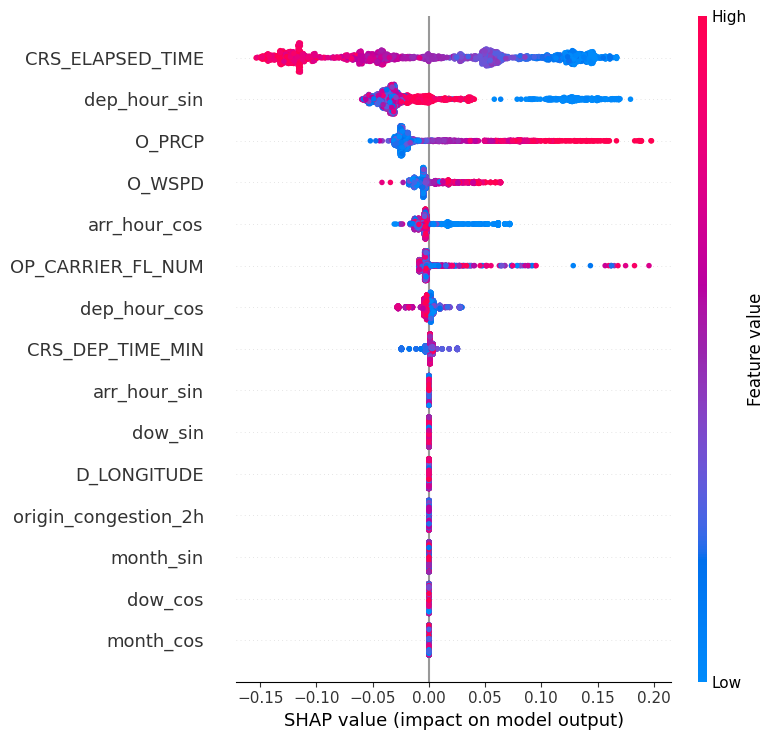

In [15]:
#!pip install -q shap

# Computed on a sample of the test set — exploratory analysis doesn't need the full set
sample = test[feature_cols].sample(n=min(2000, len(test)), random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(sample)

# Mean |SHAP| ranking — arguably more trustworthy than LightGBM's built-in gain importance,
# since it reflects actual impact on individual predictions rather than split counts
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_cols).sort_values(ascending=False)
print("Top 10 features by mean |SHAP|:")
print(mean_abs_shap.head(10))

shap.summary_plot(shap_values, sample, max_display=15)

## 9. Hyperparameter Tuning for lgbm model with Optuna

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

# scale_pos_weight, train_set and val_set are defined in train_lightgbm() (section 6) and remain local in that function
#  we recreate here a global level, so they are visible also in objective()
y_train, y_val = train[target_col], val[target_col]
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
scale_pos_weight = n_neg / max(n_pos, 1)

train_set = lgb.Dataset(train[feature_cols], label=y_train, categorical_feature=cat_cols)
val_set = lgb.Dataset(val[feature_cols], label=y_val, categorical_feature=cat_cols, reference=train_set)

def objective(trial):
    params = {
        "objective": "binary",
        "metric": "auc",
        "scale_pos_weight": scale_pos_weight,
        "verbose": -1,
        "feature_pre_filter": False,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 255),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 200),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.5, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 7),
        "lambda_l1": trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True),
    }
    model_trial = lgb.train(
        params, train_set, num_boost_round=500,
        valid_sets=[val_set], valid_names=["val"],
        callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)],
    )
    y_prob = model_trial.predict(val[feature_cols], num_iteration=model_trial.best_iteration)
    return roc_auc_score(y_val, y_prob)


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Best AUC (val):", study.best_value)
print("Best hyperparameters:", study.best_params)


##  Retrain the final model with the best hyperparameters found
best_params = {
    "objective": "binary",
    "metric": ["auc", "binary_logloss"],
    "scale_pos_weight": scale_pos_weight,
    "verbose": -1,
    "feature_pre_filter": False,
    **study.best_params,
}

model_tuned = lgb.train(
    best_params, train_set, num_boost_round=1000,
    valid_sets=[train_set, val_set], valid_names=["train", "val"],
    callbacks=[lgb.early_stopping(stopping_rounds=30), lgb.log_evaluation(period=50)],
)

metrics_tuned = evaluate(model_tuned, val, test, feature_cols, target_col)
print("\nComparison AUC test — baseline default:", metrics["auc"], "| tuned:", metrics_tuned["auc"])

Best trial: 28. Best value: 0.694379: 100%|██████████| 30/30 [03:00<00:00,  6.01s/it]


Best AUC (val): 0.6943790484369036
Best hyperparameters: {'learning_rate': 0.017456707470244862, 'num_leaves': 16, 'min_child_samples': 93, 'feature_fraction': 0.507393055284295, 'bagging_fraction': 0.9616928388113218, 'bagging_freq': 7, 'lambda_l1': 0.0024121284878001197, 'lambda_l2': 1.4572762119745828}
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[4]	train's auc: 0.680757	train's binary_logloss: 0.370578	val's auc: 0.684148	val's binary_logloss: 0.383238
Optimal threshold (on val, max F1): 0.15

=== Results on test set ===
AUC:      0.6817
F1:       0.3096
Accuracy: 0.6379  (attention: look at AUC/F1 before this!)

               precision    recall  f1-score   support

     on-time       0.92      0.64      0.75    173854
     delayed       0.21      0.62      0.31     26146

    accuracy                           0.64    200000
   macro avg       0.56      0.63      0.53    200000
weighted avg       0.83      0.64      0.70    200

## 10. Tabular MLP branch in PyTorch (embedding for future fusion with the LSTM)

Builds a second tabular model, this time a neural network instead of a tree-based one. Unlike LightGBM, this model is **differentiable end-to-end**, which matters for one specific reason: it needs to produce an **embedding** — a fixed-size vector representation of each flight — that can later be concatenated with the sequential embedding produced by the LSTM branch (built by the teammate working on flight chains), following the same double-branch architecture used in LATTICE (Chaudhuri et al., 2024) and in Aeolus itself.

Categorical features (carrier, origin/destination airport, etc.) are represented using **learned embedding layers** rather than raw integer codes — this lets the model discover, for example, that certain airports behave similarly to each other, instead of treating airport codes as arbitrary unrelated numbers.

In [17]:
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

continuous_cols = [c for c in feature_cols if c not in cat_cols]

# normalization feature continue (fit only on train) 
cont_mean = train[continuous_cols].mean()
cont_std = train[continuous_cols].std().replace(0, 1)

def normalize(df_):
    return ((df_[continuous_cols] - cont_mean) / cont_std).values.astype("float32")

# cardinality of each categorical feature (for embedding dimensions)
cardinalities = {c: int(train[c].max()) + 2 for c in cat_cols}

def cat_array(df_):
    return np.stack([
        df_[c].clip(lower=-1).replace(-1, cardinalities[c] - 1).values.astype("int64")
        for c in cat_cols
    ], axis=1)

def make_tensors(df_):
    X_cat = torch.tensor(cat_array(df_), dtype=torch.long)
    X_cont = torch.tensor(normalize(df_), dtype=torch.float32)
    y = torch.tensor(df_[target_col].values, dtype=torch.float32)
    return X_cat, X_cont, y

X_cat_train, X_cont_train, y_train_mlp = make_tensors(train)
X_cat_val, X_cont_val, y_val_mlp = make_tensors(val)
X_cat_test, X_cont_test, y_test_mlp = make_tensors(test)

pos_weight = torch.tensor(scale_pos_weight, dtype=torch.float32)  # reuse the one from Section 9

Device: cpu


In [ ]:
## Model Definition

class TabularMLP(nn.Module):
    """Tabular MLP: embedding for each categorical + MLP on continuous features.
    The 'embedding' layer (64 dim) is the one to be reused in the fusion with the LSTM."""

    def __init__(self, cardinalities, cat_cols, n_continuous, embedding_dim=64):
        super().__init__()
        self.cat_cols = cat_cols
        self.embeddings = nn.ModuleList([
            nn.Embedding(cardinalities[c], max(min(50, (cardinalities[c] + 1) // 2), 2))
            for c in cat_cols
        ])
        total_emb_dim = sum(e.embedding_dim for e in self.embeddings)

        self.mlp = nn.Sequential(
            nn.Linear(total_emb_dim + n_continuous, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, embedding_dim),
            nn.ReLU(),  # output of this layer = "tabular_embedding"
        )
        self.classifier_head = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(embedding_dim, 1),
        )

    def forward(self, x_cat, x_cont, return_embedding=False):
        embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        x = torch.cat(embs + [x_cont], dim=1)
        embedding = self.mlp(x)
        logit = self.classifier_head(embedding).squeeze(1)
        if return_embedding:
            return logit, embedding
        return logit


model_mlp = TabularMLP(cardinalities, cat_cols, n_continuous=len(continuous_cols)).to(device)
print(model_mlp)

TabularMLP(
  (embeddings): ModuleList(
    (0): Embedding(16, 8)
    (1): Embedding(9900, 50)
    (2): Embedding(3, 2)
    (3): Embedding(13, 7)
    (4): Embedding(32, 16)
    (5): Embedding(53, 27)
    (6-7): 2 x Embedding(41, 21)
  )
  (mlp): Sequential(
    (0): Linear(in_features=176, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
  )
  (classifier_head): Sequential(
    (0): Dropout(p=0.2, inplace=False)
    (1): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [ ]:
## Training loop (with early stopping)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
optimizer = torch.optim.Adam(model_mlp.parameters(), lr=1e-3)

X_cat_train, X_cont_train, y_train_mlp = X_cat_train.to(device), X_cont_train.to(device), y_train_mlp.to(device)
X_cat_val, X_cont_val, y_val_mlp = X_cat_val.to(device), X_cont_val.to(device), y_val_mlp.to(device)
X_cat_test, X_cont_test, y_test_mlp = X_cat_test.to(device), X_cont_test.to(device), y_test_mlp.to(device)

batch_size = 512
n_train = X_cat_train.shape[0]
best_val_auc, patience, patience_counter, best_state = 0.0, 5, 0, None

for epoch in range(30):
    model_mlp.train()
    perm = torch.randperm(n_train)
    epoch_loss = 0.0
    for i in range(0, n_train, batch_size):
        idx = perm[i:i + batch_size]
        xb_cat, xb_cont, yb = X_cat_train[idx], X_cont_train[idx], y_train_mlp[idx]

        optimizer.zero_grad()
        logits = model_mlp(xb_cat, xb_cont)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(idx)

    model_mlp.eval()
    with torch.no_grad():
        val_prob = torch.sigmoid(model_mlp(X_cat_val, X_cont_val)).cpu().numpy()
    val_auc = roc_auc_score(y_val_mlp.cpu().numpy(), val_prob)
    print(f"Epoch {epoch+1:2d} | train_loss={epoch_loss/n_train:.4f} | val_auc={val_auc:.4f}")

    if val_auc > best_val_auc:
        best_val_auc, patience_counter = val_auc, 0
        best_state = {k: v.clone() for k, v in model_mlp.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1} (best val_auc={best_val_auc:.4f})")
            break

model_mlp.load_state_dict(best_state)  # retake best weights

Epoch  1 | train_loss=1.1474 | val_auc=0.6786
Epoch  2 | train_loss=1.1296 | val_auc=0.6835
Epoch  3 | train_loss=1.1202 | val_auc=0.6828
Epoch  4 | train_loss=1.1106 | val_auc=0.6804
Epoch  5 | train_loss=1.0978 | val_auc=0.6752
Epoch  6 | train_loss=1.0838 | val_auc=0.6709
Epoch  7 | train_loss=1.0686 | val_auc=0.6664
Early stopping all'epoca 7 (best val_auc=0.6835)


<All keys matched successfully>

In [ ]:
## Evaluation and verification of the embedding

model_mlp.eval()
with torch.no_grad():
    test_prob = torch.sigmoid(model_mlp(X_cat_test, X_cont_test)).cpu().numpy()

auc_mlp = roc_auc_score(y_test_mlp.cpu().numpy(), test_prob)
print("AUC test (MLP PyTorch):", auc_mlp)
print("AUC test (LightGBM baseline):", metrics["auc"])
print("AUC test (LightGBM tuned):", metrics_tuned["auc"])

# verify that the embedding is extractable for future fusion with the LSTM
with torch.no_grad():
    _, emb_sample = model_mlp(X_cat_test[:5], X_cont_test[:5], return_embedding=True)
print("Shape embedding tabular extracted:", emb_sample.shape)  # expected torch.Size([5, 64])

AUC test (MLP PyTorch): 0.6820887888715048
AUC test (LightGBM baseline): 0.6821526276056823
AUC test (LightGBM tunato): 0.6896268116575642
Shape embedding tabellare estratto: torch.Size([5, 64])
